# 03 · The location-basis modifier — a within-county density relativity

**Intent.** Turn the validated signal (rural towns lose power more often than
urban ones, *within* a county) into the actual **deployable modifier**: a
multiplicative **relativity** keyed on density. New here? See
[`00_concepts.md`](../docs/00_concepts.md) and the end-to-end story
[`02_end_to_end_and_data_lineage.md`](../docs/02_end_to_end_and_data_lineage.md).

**It is a frequency relativity, mean-1 within each county** — it redistributes
risk inside a county (rural > 1, urban < 1) and nets back to the county rate; the
county baseline still owns the level. **Runtime feature = Census density only**;
PoUS is used here to *calibrate*, not at quote time.

## How it's built (physics-anchored, thin-sample-robust)

1. Rank each town's **density within its own county** (not absolute density —
   that would double-count the county baseline) → tercile: **rural** (sparsest
   third) · **mid** · **urban** (densest third).
2. Relativity per tercile = **exposure-weighted mean within-county relative**.
3. Enforce **monotone non-increasing** (denser → safer = the physics prior).
4. **Renormalize to mean-1** (conservation).
5. **v0 shadow** = cap to an attribution-confidence band `[0.80, 1.40]`, then
   renormalize again. The cap throttles how far we move price on a thin sample —
   it reflects *confidence*, not the signal size.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ANALYSIS = Path.cwd().parent
sys.path[:0] = [str(ANALYSIS), str(ANALYSIS / 'lib')]
import build_density_relativity as brd
import town_density_vs_size as tds

cells = pd.read_csv(tds.TARGET)
towns = tds.gaz.load_towns()
res = [brd.build_T(cells, towns, T) for T in brd.T_HOURS]
print(f'built from {res[0]["n_towns"]} towns across {res[0]["n_counties"]} counties (CT/MA/RI)')

built from 440 towns across 25 counties (CT/MA/RI)


/Users/divy/code/personal/renewablesinfo_org/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# the relativity table: tercile x T, empirical (uncapped) and v0-shadow (capped)
tbl = pd.DataFrame(
    {('empirical', f'T{r["T"]}'): r['empirical'] for r in res} |
    {('v0_shadow', f'T{r["T"]}'): r['v0_shadow'] for r in res},
    index=brd.TERCILES)
tbl.index.name = 'density tercile'
tbl

empirical                      v0_shadow                     
                       T1     T2     T4     T8        T1     T2     T4     T8
density tercile                                                              
rural               1.762  1.775  1.900  2.058     1.448  1.419  1.402  1.372
mid                 1.125  1.187  1.227  1.296     1.163  1.203  1.228  1.270
urban               0.789  0.753  0.708  0.640     0.827  0.811  0.801  0.784

**Read it as:** a customer in the **rural** third of their county hits the ≥T-hour
outage threshold ~1.8–2.1× as often as the county-average customer (empirical);
the **urban** third ~0.6–0.8×. The effect **widens with duration T**. The v0-shadow
column is what we'd actually run first — same shape, capped for caution.

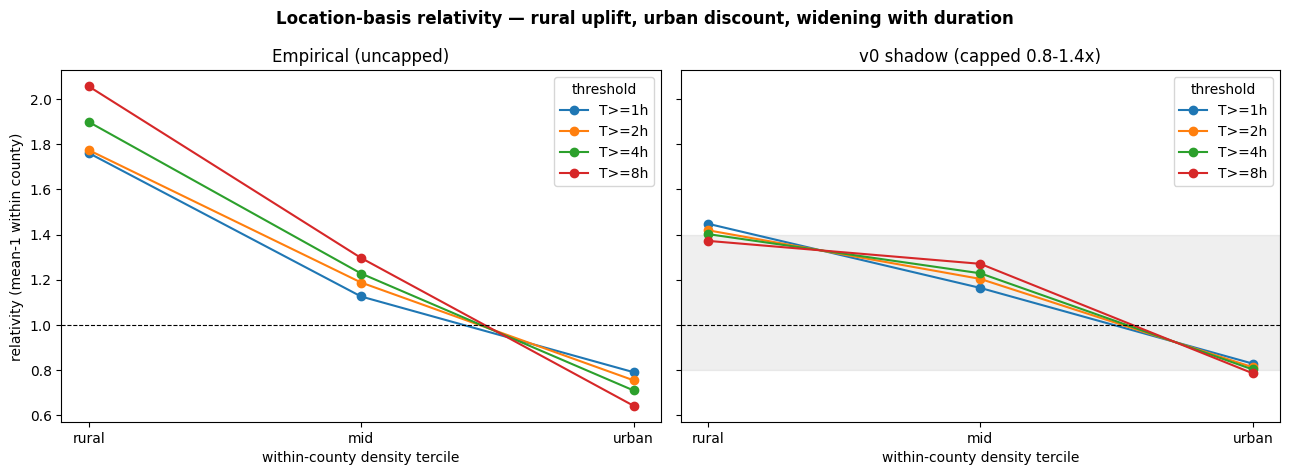

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
x = np.arange(3)
for r in res:
    ax[0].plot(x, r['empirical'], marker='o', label=f"T>={r['T']}h")
    ax[1].plot(x, r['v0_shadow'], marker='o', label=f"T>={r['T']}h")
for a, ttl in zip(ax, ['Empirical (uncapped)', 'v0 shadow (capped 0.8-1.4x)']):
    a.axhline(1.0, color='k', lw=0.8, ls='--')
    a.set_xticks(x); a.set_xticklabels(brd.TERCILES)
    a.set_xlabel('within-county density tercile'); a.set_title(ttl)
    a.legend(title='threshold')
ax[1].axhspan(brd.CAP[0], brd.CAP[1], color='grey', alpha=0.12)
ax[0].set_ylabel('relativity (mean-1 within county)')
fig.suptitle('Location-basis relativity — rural uplift, urban discount, widening with duration',
             fontweight='bold')
plt.tight_layout(); plt.show()

## Conservation check (it really is mean-1)

A modifier that *redistributes* must leave each county's total unchanged. Per
county, the exposure-weighted mean of the v0-shadow relativity should sit at ~1.0:

In [4]:
cons = pd.DataFrame([{'T': f"T>={r['T']}h", 'per-county mean (min)': r['cmean_min'],
                      'median': r['cmean_med'], 'max': r['cmean_max']} for r in res])
cons

,T,per-county mean (min),median,max
0,T>=1h,0.941,0.991,1.167
1,T>=2h,0.935,0.986,1.199
2,T>=4h,0.932,0.985,1.219
3,T>=8h,0.925,0.977,1.253


Median ~0.98–0.99 across counties — conservation holds. The spread (0.93–1.25)
is because one *universal* table is applied everywhere; **exact** per-county
mean-1 would require per-county renormalization (a refinement, not needed for a
capped v0 shadow).

## How to apply it at quote time

```text
address / lat-lon  ->  point
point              ->  county (FIPS)        and   town density (Census)
town density       ->  rank within the county's towns  ->  tercile
tercile, T         ->  relativity  (this table)
final              ->  lambda_county(T) x customer_impact x THIS relativity
```

Only **Census density** is needed at runtime; the county's town-density
distribution is precomputed (free, national). No PoUS at quote time.

## Anchor, corroboration, and honest limits

- **Physics anchor:** the monotone rural→urban direction is grid engineering
  (overhead radial feeders, vegetation, restoration distance), not just a fit —
  so the shape holds even on a thin sample.
- **Corroboration:** published density→reliability relationships support the
  slope. **EIA-861** utility reliability is a second, independent check — but it
  is *utility-grain*, so it belongs to the **grid/duration lane**, not this
  within-county density relativity; we run it there, not here (lane discipline).
- **Status: SHADOW.** Not active pricing. Validate **out-of-region** (e.g. TX,
  where trees don't saturate and the proxy may differ) before activation.
- **Limits:** one region / one quiet season; town-not-premise (the last mile
  needs live geometry / meter data); single-town numbers noisy — the *table* is
  the signal, not any one town.

## Deployable artifact

`../analysis/outputs/density_relativity.json` — the relativity by `T` and tercile
(empirical + v0_shadow), with the apply-recipe and the explicit note that runtime
depends on Census density only. This is the object the dashboard would read.